In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
df = pd.read_csv("heart.csv")

# 2 - SHAPE
# df.shape
# 2 - PRIMEIRAS LINHAS
# df.head()


# 3 - TIPOS E VALORES NULOS
info = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100).round(1)
})

info

# 4 - BALANCEAMENTO DA VARIÁVEL TARGET
vc = df.target.value_counts()
print(f" Sem doença(0): {vc[0]} amostras {vc[0]/len(df)*100:.1f}%)")
print(f" Com doença(1): {vc[1]} amostras {vc[1]/len(df)*100:.1f}%)")

# 5 - ESTATÍSTICAS DESCRITIVAS
# df.describe().round(2)

df = df.rename(columns={
    "age": "idade",
    "sex": "sexo",
    "cp": "tipo_dor_no_peito",
    "trestbps": "pressao_arterial",
    "chol": "colesterol",
    "fbs": "glicemia",
    "restecg": "eletrocardio",
    "thalac": "frq_cardiaca_max",
    "exang": "angina",
    "oldpeak": "depressao_st",
    "slope": "inclinacao_st",
    "ca": "n_vasos_color_fluoroscopia",
    "thal": "talassemia",
    "target": "alvo"
})

 Sem doença(0): 499 amostras 48.7%)
 Com doença(1): 526 amostras 51.3%)


In [4]:
df.columns

Index(['idade', 'sexo', 'tipo_dor_no_peito', 'pressao_arterial', 'colesterol',
       'glicemia', 'eletrocardio', 'thalach', 'angina', 'depressao_st',
       'inclinacao_st', 'n_vasos_color_fluoroscopia', 'talassemia', 'alvo'],
      dtype='str')

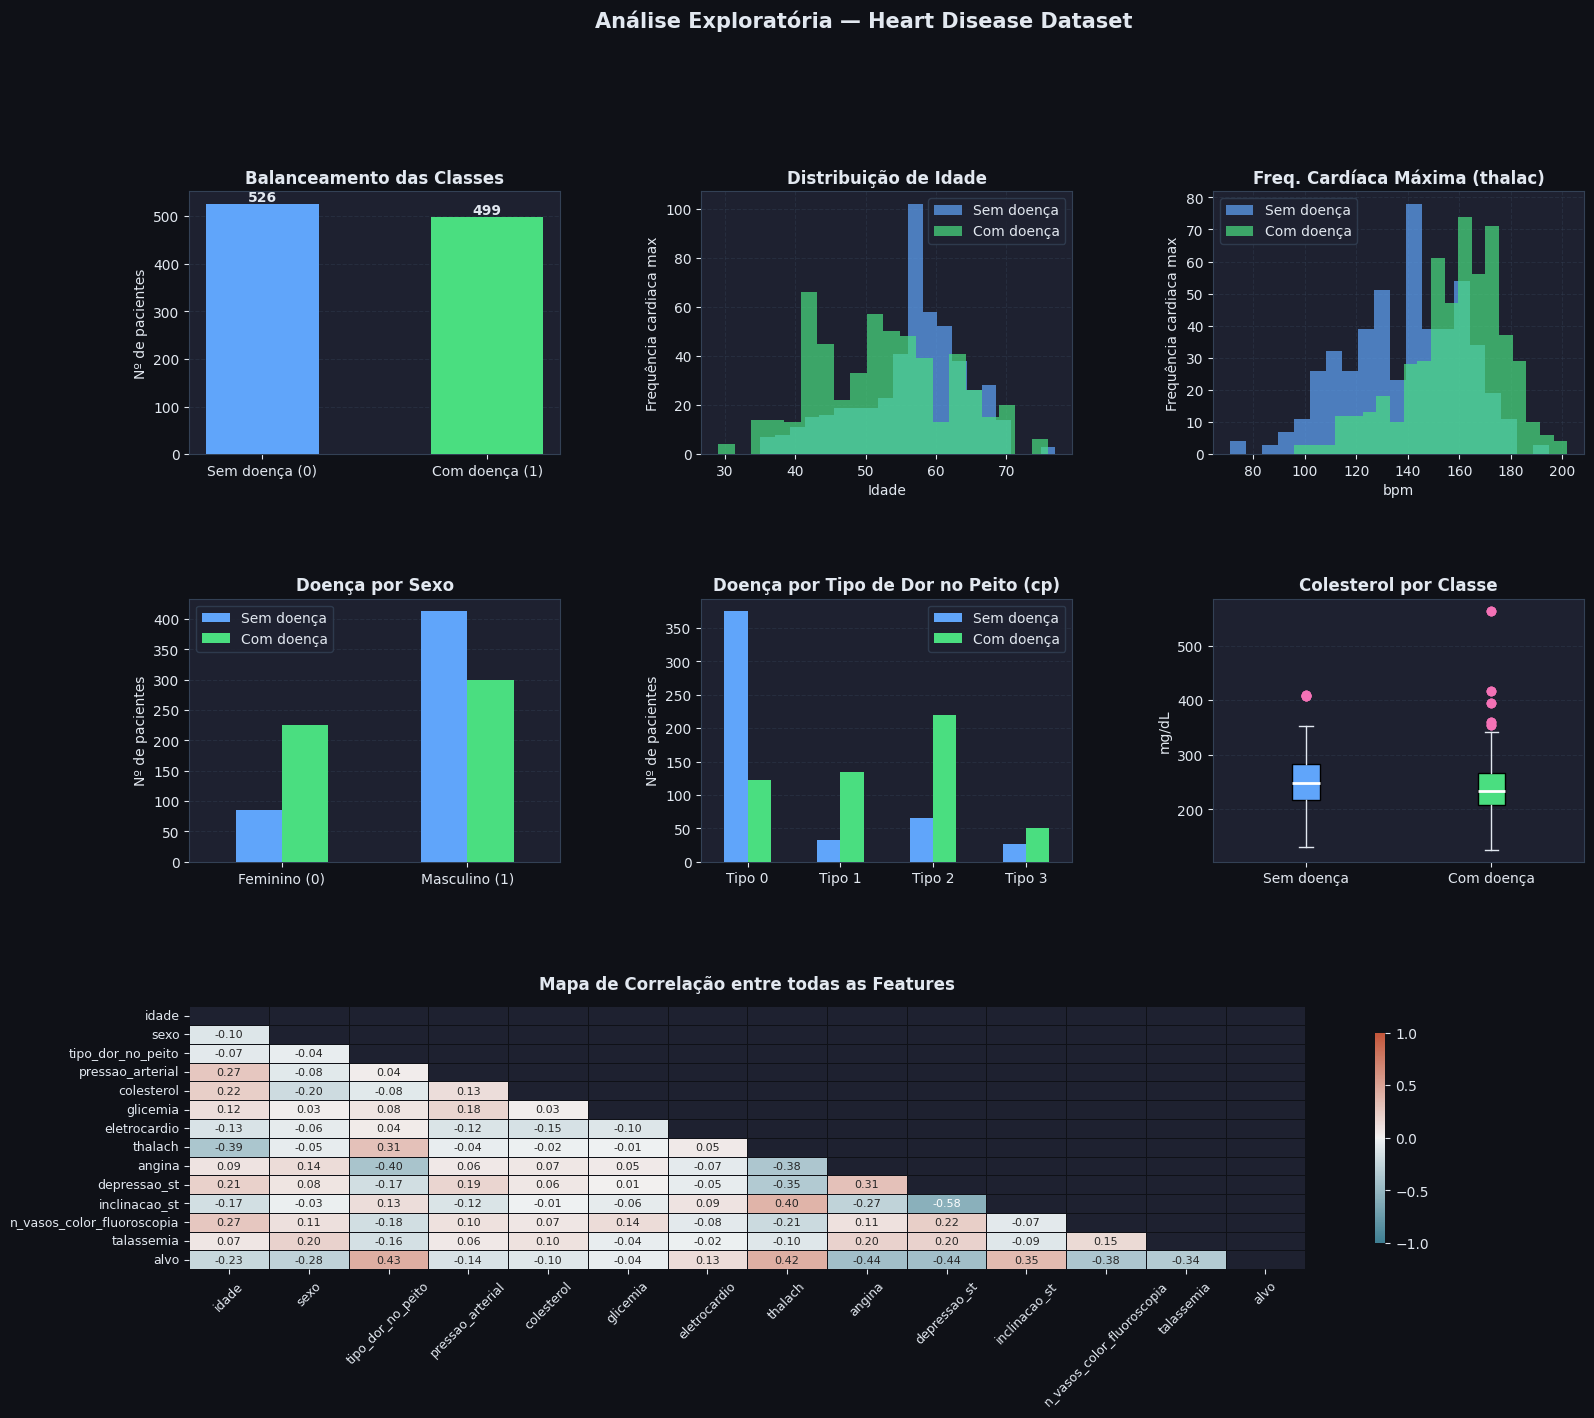

✅ Gráfico salvo: heart_eda.png


In [12]:
# ── Configuração do tema escuro ──────────────────────────────
COR_BG   = "#0f1117"   # fundo geral da figura
COR_SUB  = "#1e2130"   # fundo de cada subgráfico
COR_TXT  = "#e2e8f0"   # cor do texto
COR_GRID = "#334155"   # cor da grade e bordas
COR_POS  = "#4ade80"   # verde  → com doença (classe 1)
COR_NEG  = "#60a5fa"   # azul   → sem doença (classe 0)
COR_ACC  = "#f472b6"   # rosa   → destaque (outliers)
 
plt.rcParams.update({
    "figure.facecolor":  COR_BG,
    "axes.facecolor":    COR_SUB,
    "axes.edgecolor":    COR_GRID,
    "axes.labelcolor":   COR_TXT,
    "xtick.color":       COR_TXT,
    "ytick.color":       COR_TXT,
    "text.color":        COR_TXT,
    "grid.color":        COR_GRID,
    "grid.linestyle":    "--",
    "grid.alpha":        0.4,
})
 
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(COR_BG)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ── GRÁFICO 1 — Balanceamento das classes ────────────────────
ax1 = fig.add_subplot(gs[0, 0])
contagem = df["alvo"].value_counts()
bars = ax1.bar(
    ["Sem doença (0)", "Com doença (1)"],
    contagem.values,
    color=[COR_NEG, COR_POS], width=0.5, zorder=3
)
# Adiciona o valor numérico acima de cada barra
for bar, val in zip(bars, contagem.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(val), ha="center", color=COR_TXT, fontweight="bold")
ax1.set_title("Balanceamento das Classes", color=COR_TXT, fontweight="bold")
ax1.set_ylabel("Nº de pacientes")
ax1.grid(axis="y", zorder=0)

# ── GRÁFICO 2 — Distribuição de idade por classe ─────────────
ax2 = fig.add_subplot(gs[0, 1])
# Histograma sobreposto: cada classe com cor e transparência diferentes
ax2.hist(df[df["alvo"]==0]["idade"], bins=20, alpha=0.7,
         color=COR_NEG, label="Sem doença", zorder=3)
ax2.hist(df[df["alvo"]==1]["idade"], bins=20, alpha=0.7,
         color=COR_POS, label="Com doença", zorder=3)
ax2.set_title("Distribuição de Idade", color=COR_TXT, fontweight="bold")
ax2.set_xlabel("Idade")
ax2.set_ylabel("Frequência cardiaca max")
ax2.legend(facecolor=COR_SUB, labelcolor=COR_TXT, edgecolor=COR_GRID)
ax2.grid(zorder=0)

# GRÁFICO 3 — Frequência Cardíaca Máxima por Classe
# Objetivo: comparar o thalach (bpm) entre doentes e saudáveis
ax3 = fig.add_subplot(gs[0, 2])
 
ax3.hist(
    df[df["alvo"] == 0]["thalach"],  # thalach = frequência cardíaca máxima atingida
    bins=20, alpha=0.7,
    color=COR_NEG, label="Sem doença", zorder=3
)
ax3.hist(
    df[df["alvo"] == 1]["thalach"],
    bins=20, alpha=0.7,
    color=COR_POS, label="Com doença", zorder=3
)
 
ax3.set_title("Freq. Cardíaca Máxima (thalac)", color=COR_TXT, fontweight="bold")
ax3.set_xlabel("bpm")              # batimentos por minuto
ax3.set_ylabel("Frequência cardiaca max")
ax3.legend(facecolor=COR_SUB, labelcolor=COR_TXT, edgecolor=COR_GRID)
ax3.grid(zorder=0)


# ── GRÁFICO 4 — Doença por sexo ──────────────────────────────

ax4 = fig.add_subplot(gs[1,0])
# groupby + unstack transforma em tabela cruzada (sexo x target)
sexo_alvo = df.groupby(['sexo' , 'alvo']).size().unstack()
sexo_alvo.plot(kind="bar", ax=ax4, color=[COR_NEG, COR_POS], width=0.5, zorder=3)
ax4.set_xticklabels(["Feminino (0)", "Masculino (1)"], rotation=0)
ax4.set_title("Doença por Sexo", color=COR_TXT, fontweight="bold")
ax4.set_ylabel("Nº de pacientes")
ax4.set_xlabel("")
ax4.legend(["Sem doença", "Com doença"],
           facecolor=COR_SUB, labelcolor=COR_TXT, edgecolor=COR_GRID)
ax4.grid(axis="y", zorder=0)

# ── GRÁFICO 5 — Tipo de dor no peito (cp) ────────────────────

ax5 = fig.add_subplot(gs[1,1])
cp_alvo = df.groupby(["tipo_dor_no_peito" , "alvo"]).size().unstack()
cp_alvo.plot(kind="bar",ax= ax5, color=[COR_NEG, COR_POS], width=0.5, zorder=3)
ax5.set_xticklabels(["Tipo 0", "Tipo 1", "Tipo 2", "Tipo 3"], rotation=0)
ax5.set_title("Doença por Tipo de Dor no Peito (cp)", color=COR_TXT, fontweight="bold")
ax5.set_ylabel("Nº de pacientes")
ax5.set_xlabel("")
ax5.legend(["Sem doença", "Com doença"],
           facecolor=COR_SUB, labelcolor=COR_TXT, edgecolor=COR_GRID)
ax5.grid(axis="y", zorder=0)

# ── GRÁFICO 6 — Boxplot de colesterol por classe ─────────────
ax6 = fig.add_subplot(gs[1, 2])
# Boxplot mostra: mediana, quartis, bigodes e outliers
dados_box = [df[df["alvo"]==0]["colesterol"], df[df["alvo"]==1]["colesterol"]]
bp = ax6.boxplot(dados_box, patch_artist=True,
                 medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor(COR_NEG)
bp["boxes"][1].set_facecolor(COR_POS)
for whisker in bp["whiskers"]:
    whisker.set_color(COR_TXT)
for cap in bp["caps"]:
    cap.set_color(COR_TXT)
for flier in bp["fliers"]:      # fliers = pontos fora dos bigodes (outliers)
    flier.set_markerfacecolor(COR_ACC)
    flier.set_markeredgecolor(COR_ACC)
ax6.set_xticklabels(["Sem doença", "Com doença"])
ax6.set_title("Colesterol por Classe", color=COR_TXT, fontweight="bold")
ax6.set_ylabel("mg/dL")
ax6.grid(axis="y", zorder=0)

ax7 = fig.add_subplot(gs[2, :])   # ocupa as 3 colunas da última linha
corr = df.corr()                  # matriz de correlação de Pearson entre todas as colunas
mask = np.triu(np.ones_like(corr, dtype=bool))  # máscara para esconder o triângulo superior
# (evita duplicidade, já que a correlação é simétrica)
cmap = sns.diverging_palette(220, 20, as_cmap=True)  # paleta azul→branco→vermelho
sns.heatmap(
    corr, ax=ax7,
    mask=mask,
    cmap=cmap,
    annot=True,             # mostra os valores numéricos dentro de cada célula
    fmt=".2f",              # 2 casas decimais
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor=COR_BG,
    vmin=-1, vmax=1,        # escala fixa de -1 a +1
    center=0,               # branco no centro (correlação zero)
    cbar_kws={"shrink": 0.8}
)
ax7.set_title("Mapa de Correlação entre todas as Features",
              color=COR_TXT, fontweight="bold", pad=12)
ax7.tick_params(axis="x", rotation=45, labelsize=9)
ax7.tick_params(axis="y", rotation=0,  labelsize=9)

# ── Título geral ─────────────────────────────────────────────
fig.suptitle("Análise Exploratória — Heart Disease Dataset",
             color=COR_TXT, fontsize=15, fontweight="bold", y=1.01)
 
plt.savefig("heart_eda.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Gráfico salvo: heart_eda.png")